import statements in command prompt

1) pip install PyMuPDF
2) pip install torch
3) pip install rouge-score
4) pip install tqdm
5) pip install matplotlib


In [1]:
import os # pc files interaction
import fitz  # PyMuPDF for pdf
import re # regular expression - string manipulation
import torch # PyTorch library
import torch.nn as nn # neural networks
import math # math functions
from rouge_score import rouge_scorer # rouge score for model evaluation
from tqdm import tqdm # progress bar for loops
import matplotlib.pyplot as plt # graph visualization

step - 1: data collection

1) input files: sample dataset / legal docs
2) output files: sample dataset / summarized texts

step - 2: text extraction

In [2]:
def extract_text_from_pdf(pdf_path):
    text = ""
    doc = fitz.open(pdf_path)
    for page in doc:
        text += page.get_text()
    return text

step - 3: text cleaning

In [3]:
def clean_legal_text(text):
    text = re.sub(r"Page\s*\d+\s*of\s*\d+", "", text)
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.replace("“", '"').replace("”", '"').replace("—", "-")
    return text.strip().lower()

step - 4: data loading

In [4]:
def load_data(legal_folder, summary_folder):
    legal_texts = []
    summary_texts = []

    legal_files = sorted(os.listdir(legal_folder)) # maintaining order
    summary_files = sorted(os.listdir(summary_folder))

    for legal_file, summary_file in zip(legal_files, summary_files):
        #print(f"Loading: {legal_file} <=> {summary_file}")

        legal_path = os.path.join(legal_folder, legal_file)
        summary_path = os.path.join(summary_folder, summary_file)

        # extracting text from the pdfs
        legal_text = extract_text_from_pdf(legal_path)
        summary_text = extract_text_from_pdf(summary_path)

        # text cleaning
        legal_text = clean_legal_text(legal_text)
        summary_text = clean_legal_text(summary_text)

        # list appending
        legal_texts.append(legal_text)
        summary_texts.append(summary_text)

    return legal_texts, summary_texts

step - 5: tokenization and vocabulary building

In [5]:
class Tokenizer:
    def __init__(self):
        self.word2idx = {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3}
        self.idx2word = {0: '<pad>', 1: '<sos>', 2: '<eos>', 3: '<unk>'}
        self.vocab_size = 4

    def build_vocab(self, texts):
        for sentence in texts:
            for word in sentence.lower().split():
                if word not in self.word2idx:
                    self.word2idx[word] = self.vocab_size
                    self.idx2word[self.vocab_size] = word
                    self.vocab_size += 1

    def encode(self, text):
        return [self.word2idx.get(w, self.word2idx['<unk>']) for w in text.lower().split()]

    def decode(self, ids):
        return ' '.join(self.idx2word.get(i, '<unk>') for i in ids if i not in [0, 1, 2])

step - 6: sequence formatting

In [6]:
def pad_sequence(seq, max_len, pad_idx):
    return seq[:max_len] + [pad_idx] * max(0, max_len - len(seq))

step - 7: transformer model design

In [7]:
#positional encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=10000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        if x.size(1) > self.pe.size(1):
            raise ValueError(f"Sequence length {x.size(1)} exceeds max_len {self.pe.size(1)} in PositionalEncoding")
        return x + self.pe[:, :x.size(1)]

#scaled dot product attention
def scaled_dot_product_attention(q, k, v, mask=None):
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    attn = torch.softmax(scores, dim=-1)
    return torch.matmul(attn, v), attn

#multi head attention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_k = d_model // num_heads
        self.num_heads = num_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        q_len = q.size(1)
        k_len = k.size(1)
        v_len = v.size(1)
    
        q = self.q_linear(q).view(B, q_len, self.num_heads, self.d_k).transpose(1, 2)
        k = self.k_linear(k).view(B, k_len, self.num_heads, self.d_k).transpose(1, 2)
        v = self.v_linear(v).view(B, v_len, self.num_heads, self.d_k).transpose(1, 2)
    
        out, _ = scaled_dot_product_attention(q, k, v, mask)
        out = out.transpose(1, 2).contiguous().view(B, q_len, -1)
        return self.out(out)

#position feed forward network
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(torch.relu(self.linear1(x)))

#encoder layer
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        x2 = self.norm1(x + self.dropout(self.self_attn(x, x, x, mask)))
        return self.norm2(x2 + self.dropout(self.ffn(x2)))

#decoder layer
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, tgt_mask)))
        x = self.norm2(x + self.dropout(self.cross_attn(x, enc_output, enc_output, src_mask)))
        x = self.norm3(x + self.dropout(self.ffn(x)))
        return x

#transformer model
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=128, num_heads=8, num_layers=2, d_ff=512):
        super().__init__()
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model)

        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff) for _ in range(num_layers)
        ])
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff) for _ in range(num_layers)
        ])

        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt, src_mask, tgt_mask):
        src = self.pos_enc(self.src_embedding(src))
        tgt = self.pos_enc(self.tgt_embedding(tgt))

        for layer in self.encoder_layers:
            src = layer(src, src_mask)

        for layer in self.decoder_layers:
            tgt = layer(tgt, src, src_mask, tgt_mask)

        return self.fc_out(tgt)

    def make_src_mask(self, src):
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
        return src_mask

    def make_tgt_mask(self, tgt):
        tgt_len = tgt.size(1)
        tgt_mask = torch.tril(torch.ones((tgt_len, tgt_len), device=tgt.device)).bool()
        tgt_mask = tgt_mask.unsqueeze(0).unsqueeze(1)
        return tgt_mask

step - 8: sequence and masking

In [8]:
def prepare_sequences(legal_text, summary_text, tokenizer, max_src_len=100, max_tgt_len=30):
    src_ids = tokenizer.encode(legal_text)
    src_ids = pad_sequence(src_ids, max_src_len, tokenizer.word2idx['<pad>'])

    tgt_ids = [tokenizer.word2idx['<sos>']] + tokenizer.encode(summary_text) + [tokenizer.word2idx['<eos>']]
    tgt_ids = pad_sequence(tgt_ids, max_tgt_len, tokenizer.word2idx['<pad>'])

    src_tensor = torch.tensor([src_ids])
    tgt_input = torch.tensor([tgt_ids[:-1]])
    tgt_output = torch.tensor([tgt_ids[1:]])

    return src_tensor, tgt_input, tgt_output

def create_masks(src, tgt_input, pad_idx):
    src_mask = (src != pad_idx).unsqueeze(1).unsqueeze(2)  # (B, 1, 1, src_len)
    tgt_pad_mask = (tgt_input != pad_idx).unsqueeze(1).unsqueeze(2)  # (B, 1, 1, tgt_len)
    tgt_sub_mask = torch.tril(torch.ones((tgt_input.size(1), tgt_input.size(1)))).bool().unsqueeze(0).unsqueeze(1)
    tgt_mask = tgt_pad_mask & tgt_sub_mask  # (B, 1, tgt_len, tgt_len)
    return src_mask, tgt_mask

step - 9: model training

In [13]:
def train(model, training_data, tokenizer, epochs=50):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    loss_history = []

    for epoch in range(1, epochs + 1):
        total_loss = 0

        for sample in training_data:
            src = tokenizer.encode(sample["text"])
            tgt = tokenizer.encode(sample["summary"])

            src_tensor = torch.tensor(src).unsqueeze(0)  # (1, src_len)
            tgt_tensor = torch.tensor(tgt).unsqueeze(0)  # (1, tgt_len)

            # shift target for decoder
            decoder_input = tgt_tensor[:, :-1]
            decoder_target = tgt_tensor[:, 1:]

            # create masks
            src_mask = model.make_src_mask(src_tensor)  # (1, 1, 1, src_len)
            tgt_mask = model.make_tgt_mask(decoder_input)  # (1, 1, tgt_len, tgt_len)

            # forward pass with masks
            output = model(src_tensor, decoder_input, src_mask, tgt_mask)

            # compute loss
            loss = criterion(
                output.view(-1, output.size(-1)),
                decoder_target.view(-1)
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(training_data)
        loss_history.append(avg_loss)
        if epoch % 5 == 0:
            print(f"[Epoch {epoch}] Loss: {avg_loss:.3f}")

    return loss_history

step - 10: summary generation

In [14]:
def generate_summary(model, tokenizer, legal_text, max_len=30):
    model.eval()
    src_ids = tokenizer.encode(legal_text)
    src_ids = pad_sequence(src_ids, 100, tokenizer.word2idx['<pad>'])
    src_tensor = torch.tensor([src_ids])
    src_mask = (src_tensor != tokenizer.word2idx['<pad>']).unsqueeze(1).unsqueeze(2)

    generated = [tokenizer.word2idx['<sos>']]
    for _ in range(max_len):
        tgt_tensor = torch.tensor([generated])
        tgt_mask = create_masks(src_tensor, tgt_tensor, tokenizer.word2idx['<pad>'])[1]
        output = model(src_tensor, tgt_tensor, src_mask, tgt_mask)
        next_token = output[0, -1].argmax().item()
        if next_token == tokenizer.word2idx['<eos>']:
            break
        generated.append(next_token)

    return tokenizer.decode(generated)

step - 11: model evaluation

[Epoch 5] Loss: 5.997
[Epoch 10] Loss: 5.016
[Epoch 15] Loss: 3.775
[Epoch 20] Loss: 2.692


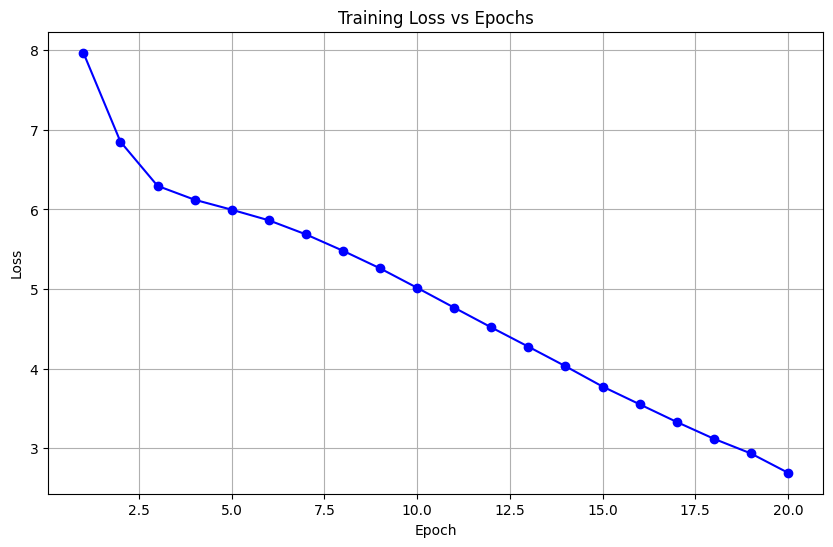


Document 1
Generated Summary:
is a case to a case registered under section 67a is not only for collection of the delhi high court has said that the accused is not guilty of section

ROUGE Evaluation:
rouge1: Precision=0.77, Recall=0.03, F1=0.05
rouge2: Precision=0.31, Recall=0.01, F1=0.02
rougeL: Precision=0.63, Recall=0.02, F1=0.04
Model Accuracy (ROUGE-L F1): 4.39%
--------------------------------------------------------------------------------

Document 2
Generated Summary:
is a case to a case registered under section 67a is not only for collection of the delhi high court has said that the accused is not guilty of section

ROUGE Evaluation:
rouge1: Precision=0.90, Recall=0.03, F1=0.05
rouge2: Precision=0.55, Recall=0.02, F1=0.03
rougeL: Precision=0.70, Recall=0.02, F1=0.04
Model Accuracy (ROUGE-L F1): 4.16%
--------------------------------------------------------------------------------

Document 3
Generated Summary:
is a case to a case registered under section 67a is not only for 

In [15]:
# load and preprocess the pdf documents
legal_folder = "C:\\Users\\marth\\Downloads\\sem4 ps proj\\talqs\\sample dataset\\legal docs"
summary_folder = "C:\\Users\\marth\\Downloads\\sem4 ps proj\\talqs\\sample dataset\\summarized texts"

legal_texts, summary_texts = load_data(legal_folder, summary_folder)

# build tokenizer and vocabulary
tokenizer = Tokenizer()
tokenizer.build_vocab(legal_texts + summary_texts)  # include both texts and summaries to build vocab

# create training data
training_data = [{"text": legal, "summary": summary} for legal, summary in zip(legal_texts, summary_texts)]

# initialize the model
model = Transformer(
    src_vocab_size=tokenizer.vocab_size,
    tgt_vocab_size=tokenizer.vocab_size,
    d_model=128,
    num_heads=8,
    num_layers=2,
    d_ff=512
)

# train the model
loss_history = train(model, training_data, tokenizer, epochs=20)

# graph plotting epochs vs loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', color='blue')
plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

#rouge score evaluation
def rouge_eval(pred, target):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = scorer.score(target, pred)
    return scores

# function to calculate accuracy based on ROUGE-L F1 score
def print_accuracy(rouge_scores):
    rouge_f1 = rouge_scores['rougeL'].fmeasure
    accuracy_percentage = rouge_f1 * 100  # to percentage
    print(f"Model Accuracy (ROUGE-L F1): {accuracy_percentage:.2f}%")
    print("-" * 80)

# generate summaries and evaluate for all documents
for idx, (legal_text, actual_summary) in enumerate(zip(legal_texts, summary_texts)):
    print(f"\nDocument {idx+1}")
    
    # generate summary for the legal document
    gen_summary = generate_summary(model, tokenizer, legal_text)
    print(f"Generated Summary:\n{gen_summary}")
    
    # evaluate the generated summary using ROUGE
    rouge_scores = rouge_eval(gen_summary, actual_summary)
    
    print("\nROUGE Evaluation:")
    for k, v in rouge_scores.items():
        print(f"{k}: Precision={v.precision:.2f}, Recall={v.recall:.2f}, F1={v.fmeasure:.2f}")
    
    # for each document
    print_accuracy(rouge_scores)